# micro-hermes — benchmark analysis

This notebook turns the raw benchmark CSVs produced by the micro-hermes simulator
into every figure and statistics table needed for the dissertation write-up.

**How to use it:** *Kernel → Restart & Run All.* That's it. The notebook will:

1. Build the simulator (release mode) and run the full benchmark matrix —
   3 dispatch policies × 4 workload cases × `TRIALS` trials — **only if** the
   results are not already present in `analysis/results/` (delete that folder to
   force fresh data).
2. Load and validate the data.
3. Produce each figure as both **PNG (300 dpi)** and **PDF** (vector, for LaTeX
   inclusion) in `analysis/figures/`, and each table as **CSV** and **LaTeX**
   (`\begin{tabular}`) in `analysis/tables/`.

Every figure section contains two pieces of dissertation-ready prose:
a **suggested caption** and a **design justification** (why this chart form,
why these axes/scales) that can be adapted directly into the methodology or
results chapters.

**Terminology used throughout** (mirrors the Hermes paper):

| Term | Meaning |
|---|---|
| `hermes` | Full closed-loop system: Algorithm 1 (userspace cascading filter → candidate bitmap) + Algorithm 2 (per-connection hash pick among candidates) |
| `lifo` | Baseline modelling `EPOLLEXCLUSIVE`'s LIFO wakeup (most-recently-blocked idle worker is woken first) |
| `reuseport` | Baseline modelling `SO_REUSEPORT`'s stateless 4-tuple hash |
| Case 1–4 | The paper's four traffic regimes: {high, low} connections-per-second × {low, high} per-connection processing cost |
| conn SD | Standard deviation of per-worker connection counts — the paper's headline balance metric (its Fig. 13) |


In [1]:
# ── Configuration, palette, and plotting style ─────────────────────────────
# All figure styling is centralised here so the whole document stays consistent.
from pathlib import Path
import subprocess, re, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Trials per (policy, case) combination. 3 gives usable error bars in ~2.5 min
# of simulation; raise for tighter confidence intervals in the final write-up.
TRIALS = 3

# Resolve repo layout whether the notebook is run from analysis/ or the root.
CWD = Path.cwd()
ANALYSIS_DIR = CWD if CWD.name == "analysis" else CWD / "analysis"
REPO_ROOT = ANALYSIS_DIR.parent
RESULTS_DIR = ANALYSIS_DIR / "results"
FIG_DIR = ANALYSIS_DIR / "figures"
TAB_DIR = ANALYSIS_DIR / "tables"
for d in (FIG_DIR, TAB_DIR):
    d.mkdir(exist_ok=True)

# Fixed policy order and colour assignment. Colours are the first three slots
# of a CVD-validated categorical palette (worst adjacent colour-vision-deficiency
# ΔE = 47.2, target ≥ 12): colour follows the *policy* identically in every
# figure, never its rank in a particular chart. Linestyles/markers provide a
# secondary encoding so the figures survive greyscale printing.
POLICIES = ["hermes", "lifo", "reuseport"]
COLOR  = {"hermes": "#2a78d6", "lifo": "#1baf7a", "reuseport": "#eda100"}
DASH   = {"hermes": "-",       "lifo": "--",      "reuseport": ":"}
MARKER = {"hermes": "o",       "lifo": "s",       "reuseport": "^"}
LABEL  = {"hermes": "Hermes", "lifo": "Epoll-exclusive (LIFO)", "reuseport": "Reuseport hash"}

CASES = {
    1: "Case 1 — high CPS, low cost",
    2: "Case 2 — high CPS, high cost (overload + hang)",
    3: "Case 3 — low CPS, long-lived",
    4: "Case 4 — low CPS, high cost",
}
NUM_WORKERS = 4

# Recessive chart chrome: hairline grid, muted axis ink, no top/right spines —
# the data marks should be the strongest ink on the page.
mpl.rcParams.update({
    "font.family": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 10.5, "axes.titleweight": "semibold",
    "axes.labelsize": 9.5, "axes.labelcolor": "#52514e",
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def save_fig(fig, name):
    # PNG for document drafts; PDF is vector, preferred for final LaTeX.
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")
    print(f"saved figures/{name}.png + .pdf")

print(f"repo root:   {REPO_ROOT}")
print(f"results dir: {RESULTS_DIR}")


repo root:   /Users/konan/Saint/Dissertation/micro_hermes
results dir: /Users/konan/Saint/Dissertation/micro_hermes/analysis/results


## 0 · Generate the benchmark data

Runs `analysis/run_benchmarks.sh`, which executes every policy × case
combination `TRIALS` times. Each trial uses a distinct `SEED`, which perturbs
the synthetic 4-tuple hash stream: trials therefore sample different
per-connection service-time sequences (reproducibly — the same seed always
yields the same stream) while holding the workload's statistical profile
fixed. Existing result files are skipped, so re-running this cell is cheap.


In [2]:
expected = len(POLICIES) * len(CASES) * TRIALS * 2  # ticks + conns per run
have = len(list(RESULTS_DIR.glob("*.csv"))) if RESULTS_DIR.exists() else 0
if have < expected:
    print(f"{have}/{expected} result files present — running benchmark matrix...")
    subprocess.run(["bash", str(ANALYSIS_DIR / "run_benchmarks.sh")],
                   env={"TRIALS": str(TRIALS), "PATH": "/usr/bin:/bin:/usr/local/bin:" + str(Path.home() / ".cargo/bin")},
                   check=True)
else:
    print(f"all {expected} result files present — skipping generation "
          f"(delete {RESULTS_DIR.relative_to(REPO_ROOT)}/ to regenerate)")


all 72 result files present — skipping generation (delete analysis/results/ to regenerate)


## 1 · Load the data

Two datasets per run:

- **`conns`** — one row per completed connection, with monotonic-clock
  timestamps for *arrival* (the simulated SYN completing, i.e. the moment the
  kernel would dispatch), *dequeue* (the worker picking the event up — the end
  of its accept-queue wait) and *done* (processing finished).
  `latency_us = done − arrival` is therefore **queueing delay + service
  time**, the quantity a client actually experiences at the load balancer.
- **`ticks`** — one row per worker event-loop iteration: a snapshot of the
  Worker Status Table (per-worker connection counts and pending events), the
  worker's own accept-queue depth, and — for Hermes only — Algorithm 1's
  per-stage survivor counts and the resulting candidate bitmap.

Timestamps are normalised to *seconds since the first event of that run*, since
the raw values come from `CLOCK_MONOTONIC` and are only meaningful within a run.


In [3]:
FNAME = re.compile(r"(?P<policy>\w+?)_case(?P<case>\d)_trial(?P<trial>\d+)_(?P<kind>ticks|conns)\.csv")

def load_all(kind):
    frames = []
    for f in sorted(RESULTS_DIR.glob(f"*_{kind}.csv")):
        m = FNAME.match(f.name)
        if not m:
            continue
        df = pd.read_csv(f)
        df["policy"] = m["policy"]
        df["case"] = int(m["case"])
        df["trial"] = int(m["trial"])
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

conns = load_all("conns")
ticks = load_all("ticks")

# Normalise to per-run elapsed seconds.
conns["t"] = conns.groupby(["policy", "case", "trial"])["arrival_ns"].transform(lambda s: (s - s.min()) / 1e9)
ticks["t"] = ticks.groupby(["policy", "case", "trial"])["timestamp_ns"].transform(lambda s: (s - s.min()) / 1e9)
conns["latency_ms"] = conns["latency_us"] / 1000.0

# Sanity checks: every (policy, case, trial) present; no negative latencies.
runs = conns.groupby(["policy", "case", "trial"]).size()
assert len(runs) == len(POLICIES) * len(CASES) * TRIALS, f"missing runs: have {len(runs)}"
assert (conns["latency_us"] >= 0).all()
print(f"{len(conns):,} connection records, {len(ticks):,} tick records across {len(runs)} runs")
runs.unstack("policy").head(8)


18,000 connection records, 30,953 tick records across 36 runs


policy      hermes  lifo  reuseport
case trial                         
1    1        1200  1200       1200
     2        1200  1200       1200
     3        1200  1200       1200
2    1         400   400        400
     2         400   400        400
     3         400   400        400
3    1         240   240        240
     2         240   240        240

## 2 · Headline statistics table

One row per policy × case, aggregated **across trials**. Percentiles are
computed *within* each trial first and then averaged across trials (reported as
mean ± sd); pooling all trials into one percentile calculation would let a
single anomalous trial dominate the tail and would hide run-to-run variance,
which is precisely what the error term is meant to expose.

Columns:

- **mean / p50 / p99 / max latency (ms)** — `p99` is the operative metric:
  load-balancer SLOs are tail-latency SLOs, and the Hermes paper evaluates on
  P99. `mean` and `p50` show the bulk; `max` bounds the worst case.
- **completed SD** — standard deviation of *completed connections per worker*
  over the whole run: the long-run fairness of the dispatch mechanism.
- **final open SD** — standard deviation of per-worker *open* connections at
  the end of the run (the paper's Fig. 13 balance metric). Most meaningful in
  Case 3, where connections are long-lived and accumulate.

The table is exported as CSV and as a LaTeX `tabular` for direct inclusion.


In [4]:
def per_trial_stats(g):
    lat = g["latency_ms"]
    per_worker = g.groupby("worker_id").size().reindex(range(NUM_WORKERS), fill_value=0)
    return pd.Series({
        "completed": len(g),
        "mean_ms": lat.mean(),
        "p50_ms": np.percentile(lat, 50),
        "p99_ms": np.percentile(lat, 99),
        "max_ms": lat.max(),
        "completed_sd": per_worker.std(ddof=0),
    })

trial_stats = (conns.groupby(["case", "policy", "trial"])
               .apply(per_trial_stats, include_groups=False).reset_index())

# Final open-connection SD: the ticks CSV already carries the cross-worker SD
# per snapshot; take each run's last snapshot.
last_tick = (ticks.sort_values("t").groupby(["case", "policy", "trial"]).tail(1)
             [["case", "policy", "trial", "conn_sd"]]
             .rename(columns={"conn_sd": "final_open_sd"}))
trial_stats = trial_stats.merge(last_tick, on=["case", "policy", "trial"])

agg = (trial_stats.groupby(["case", "policy"])
       .agg(**{c: (c, "mean") for c in ["completed", "mean_ms", "p50_ms", "p99_ms", "max_ms", "completed_sd", "final_open_sd"]},
            p99_sd=("p99_ms", "std"))
       .reset_index())
agg["policy"] = pd.Categorical(agg["policy"], POLICIES, ordered=True)
agg = agg.sort_values(["case", "policy"]).reset_index(drop=True)

display_tbl = agg.copy()
display_tbl["p99_ms"] = display_tbl.apply(lambda r: f"{r.p99_ms:.1f} ± {r.p99_sd:.1f}", axis=1)
display_tbl = display_tbl.drop(columns="p99_sd").round({"mean_ms": 1, "p50_ms": 1, "max_ms": 1, "completed_sd": 2, "final_open_sd": 2, "completed": 0})

agg.round(3).to_csv(TAB_DIR / "summary_stats.csv", index=False)
with open(TAB_DIR / "summary_stats.tex", "w") as f:
    f.write(display_tbl.to_latex(index=False,
        caption="Latency and balance statistics per dispatch policy and workload case "
                f"(mean over {TRIALS} trials; p99 reported as mean $\\pm$ sd across trials).",
        label="tab:summary-stats"))
print("saved tables/summary_stats.csv + .tex")
display_tbl


saved tables/summary_stats.csv + .tex


,case,policy,completed,mean_ms,p50_ms,p99_ms,max_ms,completed_sd,final_open_sd
0,1,hermes,1200.0,1.3,1.3,1.4 ± 0.0,1.4,15.40,5.40
1,1,lifo,1200.0,1.3,1.3,1.4 ± 0.0,2.0,514.46,23.77
2,1,reuseport,1200.0,1.5,1.3,12.0 ± 18.4,20.6,28.67,9.12
3,2,hermes,400.0,635.7,506.0,2022.5 ± 255.4,2118.2,10.13,1.46
4,2,lifo,400.0,398.9,366.6,1132.9 ± 124.5,1269.3,7.61,2.30
5,2,reuseport,400.0,784.7,609.3,2039.2 ± 272.2,2085.3,3.21,1.07
6,3,hermes,240.0,2.3,2.3,2.5 ± 0.0,2.6,15.42,15.42
7,3,lifo,240.0,2.3,2.3,2.5 ± 0.0,3.8,97.93,97.93
8,3,reuseport,240.0,2.3,2.3,2.5 ± 0.0,5.6,13.51,13.51
9,4,hermes,160.0,168.4,169.7,496.0 ± 57.8,546.9,4.85,2.18


## 3 · Figure 1 — Latency distributions (empirical CDFs)

> **Suggested caption:** *Empirical CDFs of end-to-end connection latency
> (queueing + processing) under each dispatch policy, one panel per workload
> case. Trials are pooled. The horizontal axis is logarithmic; the vertical
> gridline spacing therefore compresses the bulk of the distribution and
> expands the tail, where dispatch policies differ.*

**Design justification.** A CDF is preferred over a histogram or box plot
because the quantity of interest is "what fraction of connections complete
within *x* ms" — the exact question an SLO asks — and because it presents every
percentile simultaneously rather than a chosen few. The latency axis is
**logarithmic** since observed latencies span three orders of magnitude
(≈1 ms service-bound completions in Case 1 up to >1 s queueing under Case 2's
overload); a linear axis would render every distribution as a vertical line at
the origin. One panel per case (small multiples) rather than one combined plot,
because the four cases are different traffic *regimes* whose absolute scales
differ — the comparison that matters is between policies *within* a case.
Trials are pooled within each curve: the workload profile is identical across
trials (only the seeded service-time sequence differs), so pooling simply
smooths the empirical curve; per-trial variation is reported separately as the
error bars of Figure 2.


saved figures/fig1_latency_cdf.png + .pdf


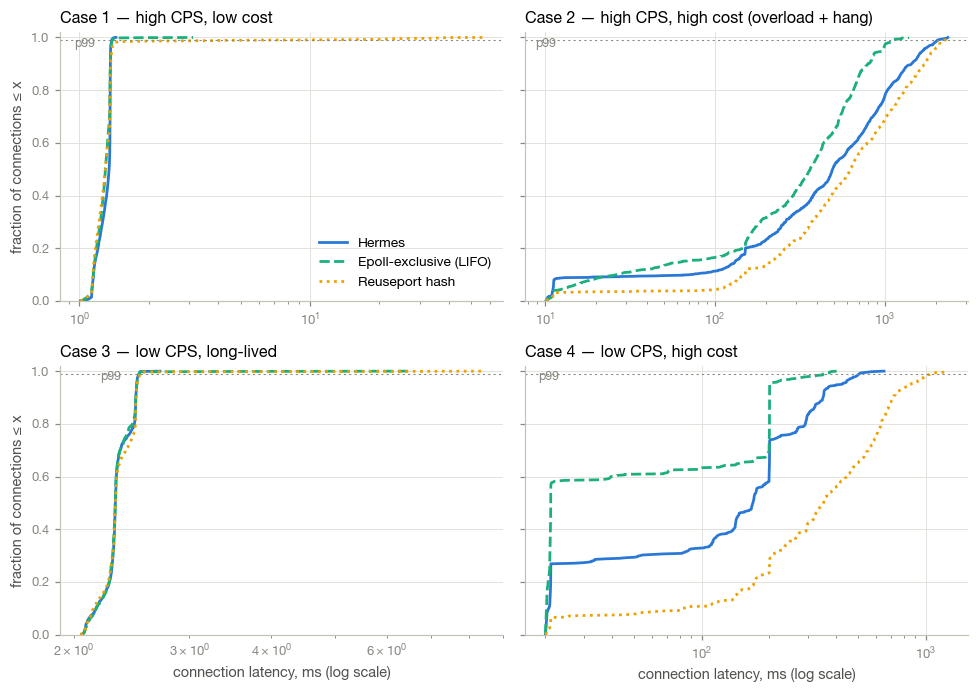

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6.4), sharey=True)
for ax, (case, title) in zip(axes.flat, CASES.items()):
    for p in POLICIES:
        lat = np.sort(conns.query("case == @case and policy == @p")["latency_ms"].values)
        cdf = np.arange(1, len(lat) + 1) / len(lat)
        ax.plot(lat, cdf, DASH[p], color=COLOR[p], lw=1.8, label=LABEL[p])
    ax.set_xscale("log")
    ax.axhline(0.99, color="#898781", lw=0.7, ls=(0, (2, 3)))
    ax.text(ax.get_xlim()[0] * 1.15, 0.965, "p99", color="#898781", fontsize=8)
    ax.set_title(title, loc="left")
    ax.set_ylim(0, 1.02)
for ax in axes[1]:
    ax.set_xlabel("connection latency, ms (log scale)")
for ax in axes[:, 0]:
    ax.set_ylabel("fraction of connections ≤ x")
axes[0, 0].legend(loc="lower right")
fig.tight_layout()
save_fig(fig, "fig1_latency_cdf")
plt.show()


## 4 · Figure 2 — Tail latency (P99) by policy and case

> **Suggested caption:** *99th-percentile connection latency per dispatch
> policy. Bars show the mean of per-trial P99 values; error bars span the
> min–max across trials. Panels use independent linear scales because the
> four cases operate in different latency regimes; comparisons are intended
> within a panel, not across panels.*

**Design justification.** Where Figure 1 shows entire distributions, this
figure isolates the single decision-relevant number (P99) with its
trial-to-trial uncertainty. Bars are used because P99 is a scalar magnitude
anchored at zero, and bar length is the most accurately decoded encoding for
that job. Each panel keeps a **linear** y-axis: a logarithmic bar chart would
break the length-proportional-to-value reading that makes bars legible, so the
regime problem is solved with per-panel scales instead of a shared log scale.
Direct value labels remove any need to read against the axis. Error bars are
the min–max across trials — never crossing below zero, which a symmetric
±sd bar would do for a low-variance latency — and consistent with the
range-based uncertainty shown in the other figures. The per-panel scale
independence is stated in the caption to prevent misreading.


saved figures/fig2_p99_bars.png + .pdf


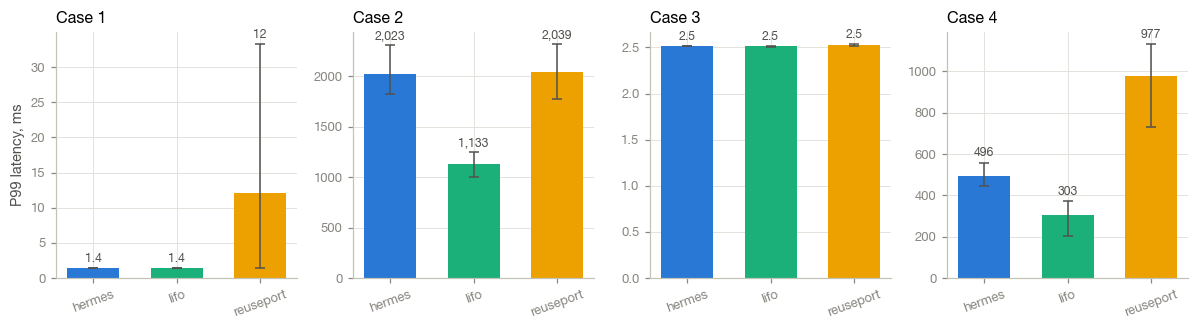

In [6]:
p99 = trial_stats.groupby(["case", "policy"])["p99_ms"].agg(["mean", "min", "max"]).reset_index()
fig, axes = plt.subplots(1, 4, figsize=(11, 3.1))
x = np.arange(len(POLICIES))
for ax, (case, title) in zip(axes, CASES.items()):
    sub = p99[p99["case"] == case].set_index("policy").reindex(POLICIES)
    err_lo, err_hi = sub["mean"] - sub["min"], sub["max"] - sub["mean"]
    ax.bar(x, sub["mean"], yerr=np.vstack([err_lo, err_hi]), width=0.62,
           color=[COLOR[p] for p in POLICIES],
           error_kw=dict(ecolor="#52514e", lw=1, capsize=3))
    for xi, v, hi in zip(x, sub["mean"], sub["max"]):
        ax.annotate(f"{v:,.1f}" if v < 10 else f"{v:,.0f}",
                    (xi, hi), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, color="#52514e")
    ax.set_title(title.split("—")[0].strip(), loc="left")
    ax.set_xticks(x, ["hermes", "lifo", "reuseport"], rotation=20)
    ax.set_ylim(bottom=0)
    ax.margins(y=0.22)
axes[0].set_ylabel("P99 latency, ms")
fig.tight_layout()
save_fig(fig, "fig2_p99_bars")
plt.show()


## 5 · Figure 3 — Load balance over time (Case 3, long-lived connections)

> **Suggested caption:** *Standard deviation of per-worker open-connection
> counts over the course of a Case 3 run (long-lived connections, none of
> which close within the run). Lines show the mean over trials in 100 ms bins;
> shaded bands span the min–max across trials. A perfectly balanced dispatcher
> holds the SD near zero as connections accumulate; under the LIFO baseline
> the SD grows roughly linearly because successive connections concentrate on
> the most recently active workers.*

**Design justification.** This reproduces the Hermes paper's headline
production comparison (its Fig. 13 uses the same statistic: the standard
deviation of per-worker connection counts). Case 3 is the natural setting
because its connections are long-lived: dispatch mistakes *accumulate* rather
than washing out as connections close, so the metric integrates the policy's
behaviour over the whole run. The x-axis is wall-clock time within the run —
balance is a property of system state, so it must be shown as a trajectory,
not a single end-of-run number (an early plateau and a late divergence would
average to the same final value while meaning very different things). The
y-axis is the cross-worker SD in units of connections, linear, anchored at
zero. Time series from different trials cannot be averaged point-for-point
(their event times differ), so curves are first resampled onto a common 100 ms
grid; the min–max band is shown rather than a standard deviation because with
three trials a range is honest while a ±sd band would suggest false precision.


saved figures/fig3_balance_over_time.png + .pdf


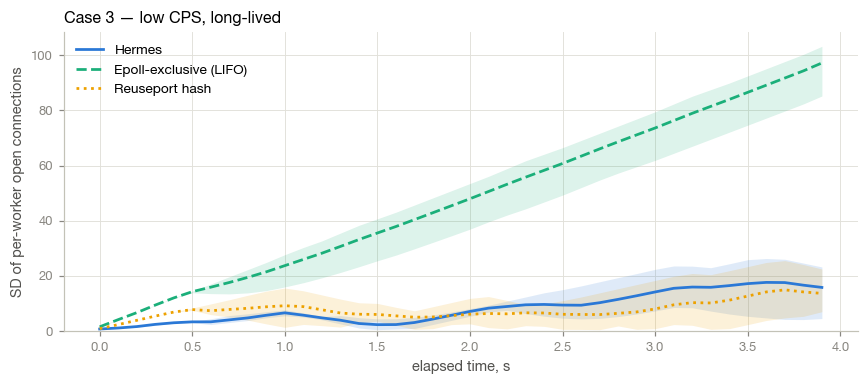

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
case = 3
for p in POLICIES:
    sub = ticks.query("case == @case and policy == @p").copy()
    sub["bin"] = (sub["t"] // 0.1) * 0.1
    per_trial = sub.groupby(["trial", "bin"])["conn_sd"].mean().unstack("trial")
    ax.plot(per_trial.index, per_trial.mean(axis=1), DASH[p], color=COLOR[p], lw=1.8, label=LABEL[p])
    ax.fill_between(per_trial.index, per_trial.min(axis=1), per_trial.max(axis=1),
                    color=COLOR[p], alpha=0.15, lw=0)
ax.set_xlabel("elapsed time, s")
ax.set_ylabel("SD of per-worker open connections")
ax.set_title(CASES[case], loc="left")
ax.legend(loc="upper left")
ax.set_ylim(bottom=0)
fig.tight_layout()
save_fig(fig, "fig3_balance_over_time")
plt.show()


## 6 · Figure 4 — Concentration profile (workers ranked by load)

> **Suggested caption:** *Connections handled per worker in a Case 3 run,
> with workers ranked within each trial from busiest to least busy (bars are
> means over trials at each rank; error bars span min–max). The dashed line
> marks the even share (total ÷ 4 = 60). Under the LIFO baseline a single
> worker absorbs nearly the entire run while the bottom two ranks are starved
> outright — the epoll-exclusive concentration pathology — whereas Hermes and
> the reuseport hash stay close to the even share at every rank.*

**Design justification.** Figure 3's SD statistic summarises imbalance; this
figure shows its *shape* — a high SD could mean one overloaded worker or one
starved worker, which have different operational consequences (overload
degrades latency; starvation wastes a core). Workers are compared **by rank
rather than by ID**: *which* physical worker LIFO concentrates onto is an
accident of startup timing (whichever registered on the wait queue last) and
changes from trial to trial, so averaging by worker ID would smear a
240-versus-0 split into four misleadingly moderate bars. The rank profile is
the trial-invariant quantity. The even-share reference line turns the chart
from relative ("bigger/smaller") into absolute ("how far from ideal"), and
min–max error bars reflect the small trial count honestly.


saved figures/fig4_concentration_profile.png + .pdf


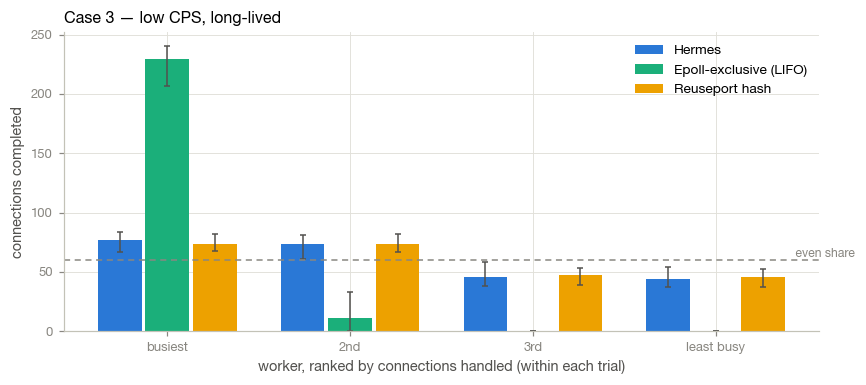

In [8]:
case = 3
per_worker = (conns.query("case == @case")
              .groupby(["policy", "trial", "worker_id"]).size()
              .reindex(pd.MultiIndex.from_product([POLICIES, range(1, TRIALS + 1), range(NUM_WORKERS)],
                                                  names=["policy", "trial", "worker_id"]), fill_value=0)
              .rename("n").reset_index())
# Rank workers within each (policy, trial): 0 = busiest.
per_worker["rank"] = per_worker.groupby(["policy", "trial"])["n"].rank(
    ascending=False, method="first").astype(int) - 1
stats = per_worker.groupby(["policy", "rank"])["n"].agg(["mean", "min", "max"]).reset_index()
# Even share: connections per run divided across the workers.
even_share = conns.query("case == @case").groupby(["policy", "trial"]).size().mean() / NUM_WORKERS

fig, ax = plt.subplots(figsize=(8, 3.6))
width = 0.26
for i, p in enumerate(POLICIES):
    sub = stats[stats["policy"] == p].set_index("rank").reindex(range(NUM_WORKERS))
    pos = np.arange(NUM_WORKERS) + (i - 1) * width
    yerr = np.vstack([sub["mean"] - sub["min"], sub["max"] - sub["mean"]])
    ax.bar(pos, sub["mean"], width=width * 0.92, color=COLOR[p], label=LABEL[p],
           yerr=yerr, error_kw=dict(ecolor="#52514e", lw=1, capsize=2))
ax.axhline(even_share, color="#898781", lw=1, ls=(0, (4, 3)))
ax.text(NUM_WORKERS - 0.58, even_share, " even share", va="bottom", fontsize=8, color="#898781")
ax.set_xticks(range(NUM_WORKERS),
              ["busiest", "2nd", "3rd", "least busy"])
ax.set_xlabel("worker, ranked by connections handled (within each trial)")
ax.set_ylabel("connections completed")
ax.set_title(CASES[case], loc="left")
ax.legend(loc="upper right")
fig.tight_layout()
save_fig(fig, "fig4_concentration_profile")
plt.show()


## 7 · Figure 5 — Hang detection in action (Case 2, Hermes)

> **Suggested caption:** *Hermes Stage-1 hang detection during a Case 2 run in
> which worker 0 is injected with a 400 ms stall (shaded). Top: worker 0's
> pending-event count as recorded in the Worker Status Table. Bottom: whether
> worker 0 is present in the scheduler's candidate bitmap (union of all
> workers' scheduling decisions per 25 ms bin). The time filter removes the
> stalled worker from candidacy ≈200 ms into the stall — the configured hang
> threshold — and readmits it after it resumes and its backlog drains.*

**Design justification.** This is the mechanism figure: it demonstrates the
causal chain *stall → stale WST timestamp → Stage-1 exclusion → recovery* that
the latency results in Figures 1–2 rely on. The two quantities have different
units (an event count vs. a binary membership), so they are shown as two
panels sharing a time axis rather than as a dual-axis plot, which would invite
false correlation reading. Candidacy is drawn as a filled 0/1 step strip — it
is a state, not a magnitude. The shaded band marks the *injected* stall window
(ground truth), letting the reader verify both the detection delay (the gap
between stall onset and candidacy dropping, bounded by the 200 ms hang
threshold) and the recovery path. Worker 0's own tick rows cease during the
stall — it is not executing its loop — so candidacy is reconstructed from all
workers' scheduler outputs, which is faithful to the system: exclusion is
enacted by the *other* workers' schedulers.


saved figures/fig5_hang_detection.png + .pdf


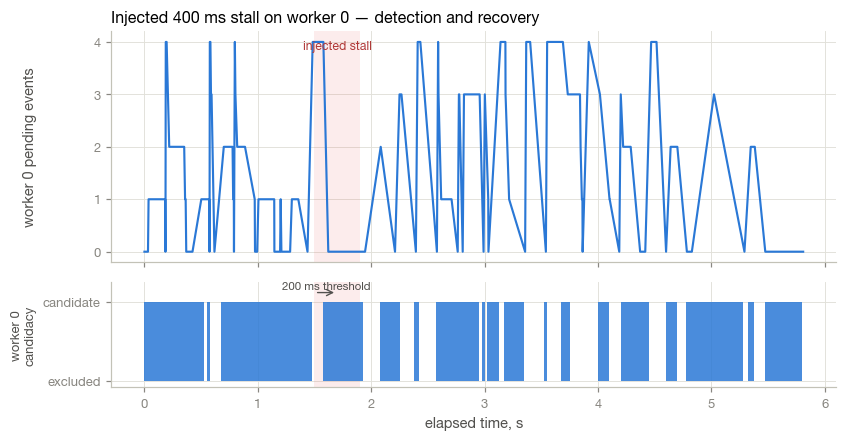

In [9]:
case, trial = 2, 1
h = ticks.query("case == @case and policy == 'hermes' and trial == @trial").sort_values("t").copy()
h["w0_candidate"] = h["bitmap_hex"].apply(lambda s: int(s, 16) & 1)
# Bin candidacy: worker 0 counts as a candidate in a bin if any scheduler
# decision in that bin included it.
h["bin"] = (h["t"] // 0.025) * 0.025
cand = h.groupby("bin")["w0_candidate"].max()
HANG_START, HANG_END, THRESHOLD = 1.5, 1.9, 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 4.2), sharex=True,
                               height_ratios=[2.2, 1], gridspec_kw=dict(hspace=0.12))
for ax in (ax1, ax2):
    ax.axvspan(HANG_START, HANG_END, color="#e34948", alpha=0.10, lw=0)
ax1.plot(h["t"], h["w0_events"], color=COLOR["hermes"], lw=1.4)
ax1.set_ylabel("worker 0 pending events")
ax1.set_title("Injected 400 ms stall on worker 0 — detection and recovery", loc="left")
ax1.annotate("injected stall", (HANG_START + (HANG_END - HANG_START) / 2, ax1.get_ylim()[1] * 0.92),
             ha="center", fontsize=8, color="#b03a39")
ax2.fill_between(cand.index, 0, cand.values, step="post", color=COLOR["hermes"], alpha=0.85, lw=0)
ax2.set_ylim(-0.08, 1.25)
ax2.set_yticks([0, 1], ["excluded", "candidate"])
ax2.set_ylabel("worker 0\ncandidacy", fontsize=8.5)
ax2.set_xlabel("elapsed time, s")
ax2.annotate("", xy=(HANG_START + THRESHOLD, 1.12), xytext=(HANG_START, 1.12),
             arrowprops=dict(arrowstyle="->", color="#52514e", lw=0.9))
ax2.text(HANG_START + THRESHOLD / 2, 1.16, "200 ms threshold", ha="center", fontsize=7.5, color="#52514e")
fig.align_ylabels()
save_fig(fig, "fig5_hang_detection")
plt.show()


## 8 · Figure 6 — Cascading filter behaviour (Hermes)

> **Suggested caption:** *Mean number of workers surviving each stage of
> Algorithm 1's cascading filter, per workload case (Hermes runs, all
> scheduler invocations pooled; error bars span ± one sd across trials of the
> per-trial means). Stage 1 removes hung workers, Stage 2 above-average
> connection counts, Stage 3 above-average pending events. The candidate set
> shrinks monotonically by construction; heavier cases prune more, matching
> the paper's observation that the fraction of workers passing the coarse
> filter decreases with load.*

**Design justification.** The three stages form an *ordered* sequence acting
on the same unit (surviving worker count), so they are encoded as an ordinal
ramp of a single hue — light to dark with stage depth — rather than three
unrelated hues, which would incorrectly suggest three independent categories.
The y-axis is bounded by the worker count (4), giving an absolute frame: a bar
at 4 means "no pruning". This figure connects the implementation back to
Algorithm 1's design intent — each stage must visibly *do work* in the regime
it was designed for (Stage 1 under hangs in Case 2; Stages 2–3 progressively
more under load) — and provides the quantitative basis for discussing filter
aggressiveness (the θ offset) in the evaluation chapter.


saved figures/fig6_cascade_stages.png + .pdf


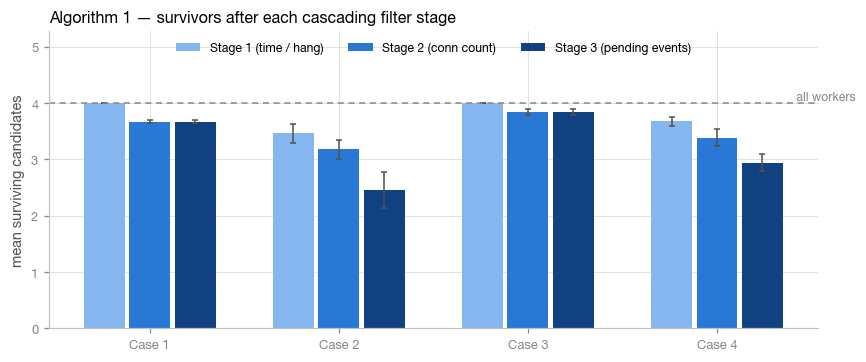

In [10]:
STAGE_COLOR = ["#86b6ef", "#2a78d6", "#104281"]  # ordinal ramp: one hue, light→dark
stages = ["after_stage1", "after_stage2", "after_stage3"]
h = ticks.query("policy == 'hermes'")
per_trial = h.groupby(["case", "trial"])[stages].mean().reset_index()
m = per_trial.groupby("case")[stages].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(CASES))
width = 0.24
for i, (st, label) in enumerate(zip(stages, ["Stage 1 (time / hang)", "Stage 2 (conn count)", "Stage 3 (pending events)"])):
    ax.bar(x + (i - 1) * width, m[(st, "mean")], yerr=m[(st, "std")], width=width * 0.9,
           color=STAGE_COLOR[i], label=label,
           error_kw=dict(ecolor="#52514e", lw=1, capsize=2))
ax.axhline(NUM_WORKERS, color="#898781", lw=1, ls=(0, (4, 3)))
ax.text(len(CASES) - 0.6, NUM_WORKERS, " all workers", va="bottom", fontsize=8, color="#898781")
ax.set_xticks(x, [f"Case {c}" for c in CASES])
ax.set_ylabel("mean surviving candidates")
ax.set_ylim(0, NUM_WORKERS * 1.32)
ax.set_title("Algorithm 1 — survivors after each cascading filter stage", loc="left")
ax.legend(loc="upper center", ncols=3, fontsize=8)
fig.tight_layout()
save_fig(fig, "fig6_cascade_stages")
plt.show()


## 9 · Qualitative validation against the paper

The Hermes paper's core claim is **adaptability**: no single baseline wins in
all four traffic regimes, but Hermes should track close to the best performer
in each. This cell checks that property mechanically and prints a verdict
table you can cite in the evaluation chapter.

Expected pattern (paper §Table 5, adapted to what a userspace simulation can
reproduce — see the caveat below):

| Case | Expectation in this simulator |
|---|---|
| 1 | Latencies indistinguishable (load is trivially light); Hermes balances best, LIFO concentrates |
| 2 | Hermes beats reuseport clearly on latency (reuseport keeps hashing onto the overloaded/hung worker) |
| 3 | Open-connection balance: Hermes ≈ reuseport, both ≪ LIFO. (The paper's production Hermes-beats-reuseport margin comes from variable connection durations degrading the hash's balance over time; Case 3's synthetic connections are identical and never close, so the hash is near-optimal here and parity is the faithful expectation.) |
| 4 | Hermes and LIFO both far ahead of reuseport; Hermes slightly behind LIFO (feedback lag vs. immediate wakeup) |

**Caveat for the write-up:** in Cases 2 and 4 the LIFO baseline posts the best
raw latency here, whereas the paper ranks epoll-exclusive below Hermes in
Case 2. This is a *simulation boundary*, not a bug: the simulator cannot
reproduce epoll-exclusive's real kernel-side costs (O(#ports) wait-queue
traversal and wakeup overhead across many listen sockets — this simulation has
a single port), and with those absent its all-busy path approximates an ideal
work-conserving central queue. The dissertation should present the latency
results alongside this limitation.


In [11]:
g = agg.set_index(["case", "policy"])
checks = [
    ("C1: policies within 25% on p50 (latency parity)",
     g.loc[(1, slice(None)), "p50_ms"].max() / g.loc[(1, slice(None)), "p50_ms"].min() < 1.25),
    ("C1: hermes best completed-balance",
     g.loc[(1, "hermes"), "completed_sd"] == g.loc[(1, slice(None)), "completed_sd"].min()),
    # Mean latency rather than p99 for the C2 comparison: under sustained
    # overload the p99 is set by the end-of-run backlog drain and varies
    # hundreds of ms between trials, while the mean is stable.
    ("C2: hermes mean latency beats reuseport",
     g.loc[(2, "hermes"), "mean_ms"] < g.loc[(2, "reuseport"), "mean_ms"]),
    # Paper §10 case 3 at low CPS: "Hermes ≈ Reuseport > exclusive". The
    # Hermes balance *advantage* only appears under heavy load or traffic
    # with variable connection duration; here every connection is identical
    # and never closes, so the stateless hash is near-optimal by
    # construction and parity is the correct expectation.
    ("C3: LIFO open-conn SD > 3x both alternatives (concentration)",
     g.loc[(3, "lifo"), "final_open_sd"] > 3 * max(g.loc[(3, "hermes"), "final_open_sd"],
                                                   g.loc[(3, "reuseport"), "final_open_sd"])),
    ("C3: hermes ≈ reuseport open-conn SD (within 1.5x)",
     g.loc[(3, "hermes"), "final_open_sd"] < 1.5 * g.loc[(3, "reuseport"), "final_open_sd"]),
    ("C4: hermes p99 beats reuseport by >1.5x",
     g.loc[(4, "hermes"), "p99_ms"] * 1.5 < g.loc[(4, "reuseport"), "p99_ms"]),
    ("All: hermes never the worst p99 in any case",
     all(g.loc[(c, "hermes"), "p99_ms"] < g.loc[(c, slice(None)), "p99_ms"].max() * 0.999 or
         g.loc[(c, slice(None)), "p99_ms"].max() / g.loc[(c, slice(None)), "p99_ms"].min() < 1.25
         for c in CASES)),
]
verdicts = pd.DataFrame(checks, columns=["expectation", "holds"])
verdicts["holds"] = verdicts["holds"].map({True: "✓ PASS", False: "✗ FAIL"})
verdicts.to_csv(TAB_DIR / "validation_verdicts.csv", index=False)
print("saved tables/validation_verdicts.csv")
verdicts


saved tables/validation_verdicts.csv


,expectation,holds
0,C1: policies within 25% on p50 (latency parity),✓ PASS
1,C1: hermes best completed-balance,✓ PASS
2,C2: hermes mean latency beats reuseport,✓ PASS
3,C3: LIFO open-conn SD > 3x both alternatives (...,✓ PASS
4,C3: hermes ≈ reuseport open-conn SD (within 1.5x),✓ PASS
5,C4: hermes p99 beats reuseport by >1.5x,✓ PASS
6,All: hermes never the worst p99 in any case,✓ PASS


## 10 · Output inventory

Everything produced by this notebook, ready to pull into the dissertation.
PDFs are vector and should be preferred for LaTeX (`\includegraphics`); PNGs
are for drafts and slide decks.


In [12]:
for d in (FIG_DIR, TAB_DIR):
    print(f"{d.relative_to(REPO_ROOT)}/")
    for f in sorted(d.iterdir()):
        print(f"  {f.name:36s} {f.stat().st_size / 1024:7.1f} KB")


analysis/figures/
  fig1_latency_cdf.pdf                    52.3 KB
  fig1_latency_cdf.png                   288.8 KB
  fig2_p99_bars.pdf                       18.3 KB
  fig2_p99_bars.png                      102.7 KB
  fig3_balance_over_time.pdf              23.9 KB
  fig3_balance_over_time.png             159.2 KB
  fig4_concentration_profile.pdf          20.3 KB
  fig4_concentration_profile.png          95.5 KB
  fig5_hang_detection.pdf                 18.7 KB
  fig5_hang_detection.png                204.5 KB
  fig6_cascade_stages.pdf                 17.5 KB
  fig6_cascade_stages.png                 73.0 KB
analysis/tables/
  summary_stats.csv                        0.8 KB
  summary_stats.tex                        1.6 KB
  validation_verdicts.csv                  0.4 KB
